In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
from ipywidgets import interact

Данный пример показывает как можно применить виджет Jupyter Notebook'а `interact` для создания ползунка, изменяющего любое количество переменных, влияющих на итоговую картинку. Это простейший способ добавления интерактивности.

Вначале рассмотрим простую программу, русующую окружность с центров в начале координат. Затем изменим ее так, чтобы центр окружностит можно было двигать в любую точку.

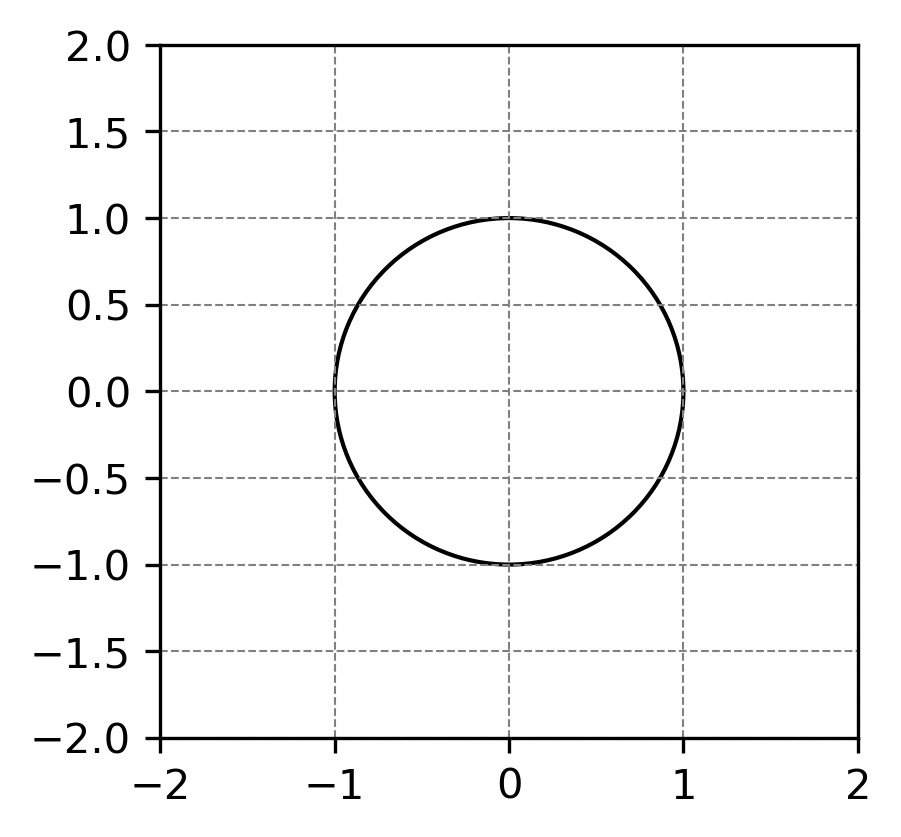

In [3]:
# Все рисунки начинаются с оздания фигуры и осей координат на данной фигуре
# указывается номер фигуры, ее размер в дюймах и плотность пикселей (число точек на дюйм, dot per inch — dpi)
fig = plt.figure(num=1, figsize=(3, 3), dpi=300)
ax = fig.add_subplot(1, 1, 1)
# Включаем отображение сетки координат. Она нужна всегда, так как очень 
# важно соблюдение одинакового масштаба осей воизбежания деформации длин и углов
ax.grid(visible=True, color='grey', lw=0.5, ls='--')
# Также устанавливаем лимиты по осям координат. В данном примере это особенно важно, так как 
# окружность мы рисуем с помощью объекта Citcle и matplotlib автоматически не будет подстраивать
# размеры системы координат так, чтобы окружность попала в поле зрения
ax.set(
    xlim=(-2, 2),
    ylim=(-2, 2)
)
# Задаем окружность
C = mpatches.Circle(xy=(0, 0), radius=1, fill=False)
# добавляем ее на рисунок
ax.add_patch(C)
# Если все настроено правильно, то никаких plt.show() вызывать не нужно

Теперь тот же самый код помести в функцию. Вместо фиксированной точки центра окружности зададим ее кординаты двумя аргументами функции `x_0` и `y_0`

In [4]:
def plot_circle(x_0=0, y_0=0):
    fig = plt.figure(num=1, figsize=(3, 3), dpi=300)
    ax = fig.add_subplot(1, 1, 1)
    ax.grid(visible=True, color='grey', lw=0.5, ls='--')
    ax.set(
        xlim=(-2, 2),
        ylim=(-2, 2)
    )
    C = mpatches.Circle(xy=(x_0, y_0), radius=1, fill=False)
    ax.add_patch(C)

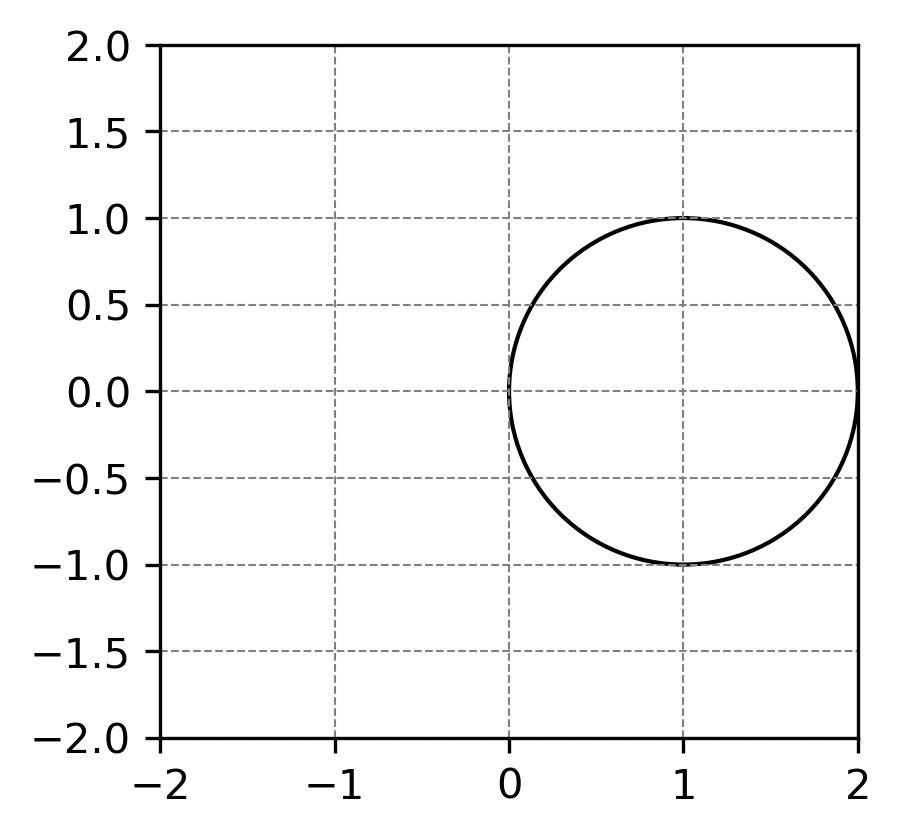

In [5]:
# Вызовем функцию и убедимся, что все работает
plot_circle(x_0=1, y_0=0)

А теперь с помощью функции `interact` те же самы переменные зададим в виде ползунков

In [6]:
interact(plot_circle, x_0=(0, 1, 0.01), y_0=(0, 1, 0.01))

interactive(children=(FloatSlider(value=0.0, description='x_0', max=1.0, step=0.01), FloatSlider(value=0.0, de…

<function __main__.plot_circle(x_0=0, y_0=0)>

Если у вас при движении ползунков се прыгает и скачет, то используйте следующий код. Он заранее задает высоту области вывода и это предотвращает скачки изображения при перемещении ползунка

In [7]:
interactive_plot = interact(plot_circle, x_0=(-1, 1, 0.01), y_0=(-1, 1, 0.01))
output = interactive_plot.widget.children[-1]
output.layout.height = '1000px'
interactive_plot

interactive(children=(FloatSlider(value=0.0, description='x_0', max=1.0, min=-1.0, step=0.01), FloatSlider(val…

<function __main__.plot_circle(x_0=0, y_0=0)>

In [8]:
interactive_plot = interact(lambda α: plot_circle(x_0=np.cos(α), y_0=np.sin(α)), α=(-np.pi, np.pi, 0.01))
output = interactive_plot.widget.children[-1]
output.layout.height = '1000px'
interactive_plot

interactive(children=(FloatSlider(value=-0.0015926535897929917, description='α', max=3.141592653589793, min=-3…

<function __main__.<lambda>(α)>